In [2]:
pip install p_tqdm


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: /Users/zheguan/.pyenv/versions/3.10.13/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install dcor


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: /Users/zheguan/.pyenv/versions/3.10.13/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install iisignature


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: /Users/zheguan/.pyenv/versions/3.10.13/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [10]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.linear_model import TheilSenRegressor
from sklearn.linear_model import LinearRegression

In [11]:
# Read the CSV file
df1 = pd.read_csv('../../Data/daily_price.csv')

data = df1.set_index('ticker')

data

,ROSE,ANKR,VET,NEAR,ETH,EOS,BAKE,GRT,REEF,INJ,...,ENJ,CAKE,XRP,TRX,ATOM,AAVE,DOGE,NEO,SAND,QTUM
ticker,,,,,,,,,,,,,,,,,,,,,
1/1/2021,0.04210,0.008912,0.019052,1.3587,728.91,2.6378,NaN,0.36169,0.012224,4.0817,...,0.13561,NaN,0.23746,0.02685,5.861,90.711,0.005680,14.461,0.036973,2.268
1/2/2021,0.04095,0.008557,0.019993,1.4124,774.56,2.6321,NaN,0.32751,0.011317,3.6083,...,0.13156,NaN,0.22064,0.02721,5.420,85.768,0.010526,14.426,0.038107,2.249
1/3/2021,0.04129,0.008610,0.026226,1.4707,978.28,2.7985,NaN,0.29857,0.009871,4.4294,...,0.13500,NaN,0.22540,0.02949,5.829,93.778,0.009821,16.024,0.040928,2.466
1/4/2021,0.04135,0.008397,0.024598,1.3868,1041.43,2.8191,NaN,0.30888,0.010121,4.3500,...,0.14105,NaN,0.23565,0.03095,6.044,114.271,0.009761,16.372,0.040432,2.515
1/5/2021,0.04394,0.008499,0.027964,1.4953,1099.56,2.8862,NaN,0.33823,0.010981,4.5700,...,0.14654,NaN,0.22573,0.02852,6.196,119.689,0.009970,16.868,0.041700,2.612
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6/26/2024,0.09229,0.030890,0.025950,5.1770,3371.44,0.5750,0.2740,0.21870,0.001415,23.0400,...,0.19980,2.151,0.46980,0.12268,6.791,94.460,0.122760,11.340,0.334000,2.566
6/27/2024,0.09734,0.031490,0.026690,5.2230,3450.44,0.5894,0.2786,0.21780,0.001451,23.2400,...,0.19620,2.182,0.47530,0.12201,6.965,93.460,0.127110,11.620,0.340700,2.607
6/28/2024,0.09674,0.030630,0.026650,4.9620,3380.15,0.5875,0.2672,0.20730,0.001418,23.0700,...,0.19100,2.134,0.47160,0.12321,6.729,93.640,0.123060,11.400,0.336100,2.571


In [12]:
os.path

<module 'posixpath' from '/Users/zheguan/.pyenv/versions/3.10.13/lib/python3.10/posixpath.py'>

In [13]:
'''

2. DATA_PREPARATION

'''

'\n\n2. DATA_PREPARATION\n\n'

In [14]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from functools import partial
import pickle

In [15]:
# row t: gives the log return going from the close at day t - 1 to close at day t
daily_ret = np.log(data).ffill().diff().shift(-1).fillna(0)
daily_ret = daily_ret[:-1]

In [16]:
close_price = data.shift(-1).fillna(0)
close_price = close_price[:-1]

In [17]:
daily_ret = np.log(data).ffill().diff().fillna(0)
daily_ret = daily_ret[1:]

In [18]:
close_price = data[1:]

In [19]:
daily_ret

,ROSE,ANKR,VET,NEAR,ETH,EOS,BAKE,GRT,REEF,INJ,...,ENJ,CAKE,XRP,TRX,ATOM,AAVE,DOGE,NEO,SAND,QTUM
ticker,,,,,,,,,,,,,,,,,,,,,
1/2/2021,-0.027696,-0.040649,0.048210,0.038762,0.060745,-0.002163,0.000000,-0.099269,-0.077095,-0.123277,...,-0.030320,0.000000,-0.073467,0.013319,-0.078224,-0.056033,0.616935,-0.002423,0.030210,-0.008413
1/3/2021,0.008269,0.006175,0.271369,0.040448,0.233501,0.061302,0.000000,-0.092514,-0.136705,0.205027,...,0.025812,0.000000,0.021344,0.080467,0.072750,0.089284,-0.069374,0.105055,0.071416,0.092112
1/4/2021,0.001452,-0.025050,-0.064086,-0.058740,0.062554,0.007334,0.000000,0.033948,0.025011,-0.018088,...,0.043840,0.000000,0.044471,0.048322,0.036221,0.197643,-0.006087,0.021485,-0.012193,0.019675
1/5/2021,0.060753,0.012074,0.128253,0.075328,0.054315,0.023523,0.000000,0.090773,0.081554,0.049337,...,0.038184,0.000000,-0.043008,-0.081767,0.024838,0.046324,0.021155,0.029846,0.030880,0.037843
1/6/2021,0.076430,0.073915,0.097213,0.030299,0.094404,0.155298,0.000000,0.089534,-0.060727,0.004062,...,0.088188,0.000000,0.096264,0.065809,0.075513,-0.038305,0.044146,0.146789,0.068465,0.142820
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6/26/2024,-0.005834,-0.032487,-0.017950,-0.046792,-0.006937,-0.002779,-0.007273,-0.007743,-0.022363,-0.016785,...,-0.021293,-0.010176,-0.012480,0.006460,-0.021704,0.025410,-0.027240,-0.013141,-0.010721,-0.004666
6/27/2024,0.053274,0.019238,0.028117,0.008846,0.023162,0.024735,0.016649,-0.004124,0.025123,0.008643,...,-0.018182,0.014309,0.011639,-0.005476,0.025299,-0.010643,0.034822,0.024391,0.019861,0.015852
6/28/2024,-0.006183,-0.027690,-0.001500,-0.051263,-0.020582,-0.003229,-0.041780,-0.049410,-0.023006,-0.007342,...,-0.026861,-0.022244,-0.007815,0.009787,-0.034471,0.001924,-0.032381,-0.019114,-0.013594,-0.013905


In [20]:
import scipy.stats as stats

# winsorization function for a single stock
def winsorize_stock(stock_returns, lower_percentile, upper_percentile):
    return stats.mstats.winsorize(stock_returns, limits=[lower_percentile, 1-upper_percentile])

# Apply the function to each column (stock)
daily_ret = daily_ret.apply(winsorize_stock, lower_percentile=0.025, upper_percentile=0.975)

In [21]:
daily_ret.describe()

,ROSE,ANKR,VET,NEAR,ETH,EOS,BAKE,GRT,REEF,INJ,...,ENJ,CAKE,XRP,TRX,ATOM,AAVE,DOGE,NEO,SAND,QTUM
count,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,...,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000
mean,0.000810,0.000477,0.000485,0.000868,0.001444,-0.001100,-0.002834,-0.000654,-0.001050,0.001740,...,0.000110,-0.001629,-0.000389,0.001082,0.000364,0.000227,0.001180,-0.000099,0.000385,0.000026
std,0.057853,0.051228,0.049198,0.059338,0.036760,0.044803,0.055807,0.056779,0.053173,0.061438,...,0.054552,0.043477,0.039897,0.033567,0.051310,0.051551,0.052678,0.046783,0.056759,0.049709
min,-0.126276,-0.115381,-0.112083,-0.132678,-0.087733,-0.118940,-0.143364,-0.128403,-0.124426,-0.135480,...,-0.122273,-0.112093,-0.098959,-0.093753,-0.113157,-0.118320,-0.110154,-0.111055,-0.134184,-0.115339
25%,-0.032884,-0.029607,-0.027533,-0.032568,-0.017723,-0.023444,-0.031005,-0.034420,-0.030304,-0.034315,...,-0.031973,-0.022240,-0.020526,-0.013947,-0.028267,-0.029532,-0.027122,-0.026015,-0.030927,-0.026266
50%,-0.000098,0.001587,0.000652,-0.000798,0.000927,0.000000,0.000000,-0.001516,0.000000,-0.000835,...,0.001472,0.000000,0.000060,0.002333,0.000371,0.000020,-0.000645,0.002216,-0.000272,0.002242
75%,0.031302,0.027897,0.027477,0.033793,0.021865,0.023824,0.028573,0.030803,0.027496,0.034874,...,0.029604,0.020097,0.020227,0.015931,0.027073,0.028842,0.021321,0.027133,0.029209,0.026291
max,0.150636,0.125301,0.125841,0.144168,0.087468,0.105065,0.126132,0.140632,0.126721,0.154830,...,0.138115,0.106142,0.102540,0.094108,0.131534,0.122575,0.171577,0.105118,0.151228,0.129443


In [22]:
def standardize_returns(returns):
    """
    Standardizes asset returns such that their mean is zero and standard deviation is one.

    Parameters:
    returns (pd.DataFrame): DataFrame with asset returns where rows are time periods and columns are assets.

    Returns:
    pd.DataFrame: Standardized returns with mean 0 and standard deviation 1.
    """
    # Compute mean and standard deviation for each asset
    mean_returns = returns.mean()
    std_returns = returns.std()

    # Standardize returns
    standardized_returns = (returns - mean_returns) / std_returns

    return standardized_returns

In [23]:
daily_ret = standardize_returns(daily_ret)

In [24]:
daily_ret.to_csv('./data/binance_real_data/daily_returns.csv')
daily_ret.to_pickle('./data/binance_real_data/daily_returns.pkl')

In [25]:
daily_ret = daily_ret.rename_axis("date")

In [41]:
"""

4. EXPLORE THE LEAD-LAG MATRIX AND RESULTING CLUSTERING ACROSS TIME SCALE

"""

'\n\n4. EXPLORE THE LEAD-LAG MATRIX AND RESULTING CLUSTERING ACROSS TIME SCALE\n\n'

In [35]:
log_ret_type = '' # '_residuals'
correlation_method = 'mutual_information'
method = 'signature'

lead_lag_matrix = pd.read_pickle('./data/binance_pickled_data/lead_lag_matrix' + log_ret_type + '_' + correlation_method + '_' + method + '.pkl')

In [28]:
from importlib import reload
import itertools
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from models.lead_lag_measure import get_lead_lag_matrix
from models.herm_matrix_algo import get_ordered_clustering
import real_data.utils
from real_data.utils import get_ordered_matrix, compute_jaccard, compute_flow_graph, plot_flow_heatmap, \
    plot_flow_network
import real_data.rolling_utils
from real_data.rolling_utils import get_rolling_lead_lag_matrix, get_cluster_rolling_metric, get_flow_graph_rolling

In [18]:
log_ret_type = ''  # _residuals
lookback = 30 # 1 month lookback period
update_freq = 1 # (1, 7, 14, 30)
correlation_method = 'pearson'  # ''
method = 'ccf_at_max_lag'

daily_ret.index = pd.to_datetime(daily_ret.index)

lead_lag_matrix_rolling = get_rolling_lead_lag_matrix(daily_ret, lookback=lookback,
                                                      update_freq=update_freq,
                                                      method=method, max_lag=7, correlation_method=correlation_method)
lead_lag_matrix_rolling.to_pickle('./data/binance_pickled_data/lead_lag_matrix_rolling' + '_lookback_' + str(lookback) +
                                  '_update_freq_' + str(update_freq) + log_ret_type + '_' + correlation_method + '_' + method + '.pkl')


  0%|          | 0/534 [00:00<?, ?it/s]

In [107]:
import pandas as pd
import matplotlib.pyplot as plt

lookback = 30
update_freq = 1
log_ret_type = ''
correlation_method = 'pearson'

base_path = './data/binance_pickled_data/lead_lag_matrix_rolling'
path_ccf = f'{base_path}_lookback_{lookback}_update_freq_{update_freq}{log_ret_type}_{correlation_method}_ccf_at_max_lag.pkl'
path_sig = f'{base_path}_lookback_{lookback}_update_freq_{update_freq}{log_ret_type}_pearson_signature.pkl'
path_dis = f'{base_path}_lookback_{lookback}_update_freq_{update_freq}{log_ret_type}_distance_ccf_at_max_lag.pkl'

lead_lag_ccf = pd.read_pickle(path_ccf)
lead_lag_sig = pd.read_pickle(path_sig)
lead_lag_dis = pd.read_pickle(path_dis)
lead_lag_ccf = lead_lag_ccf[lead_lag_ccf.index >= '2021-05-01']
lead_lag_sig = lead_lag_sig[lead_lag_sig.index >= '2021-05-01']
lead_lag_dis = lead_lag_dis[lead_lag_dis.index >= '2021-05-01']



In [106]:
lead_lag_ccf

2021-02-01              ROSE      ANKR       VET      NEAR  ...
2021-02-03              ROSE      ANKR       VET      NEAR  ...
2021-02-05              ROSE      ANKR       VET      NEAR  ...
2021-02-09              ROSE      ANKR       VET      NEAR  ...
2021-02-11              ROSE      ANKR       VET      NEAR  ...
                                    ...                        
2024-06-20              ROSE      ANKR       VET      NEAR  ...
2024-06-22              ROSE      ANKR       VET      NEAR  ...
2024-06-25              ROSE      ANKR       VET      NEAR  ...
2024-06-27              ROSE      ANKR       VET      NEAR  ...
2024-06-29              ROSE      ANKR       VET      NEAR  ...
Length: 534, dtype: object

In [108]:
def backtest_from_lead_lag_rolling(prices, lead_lag_matrix_rolling, quantile=0.1):
    log_returns = np.log(prices).diff()
    log_returns.index = pd.to_datetime(log_returns.index)
    log_returns = log_returns.sort_index() 
    print("Log return index sorted?:", log_returns.index.is_monotonic_increasing)
    print("Log return index unique?:", log_returns.index.is_unique)

    daily_returns = []
    backtest_dates = []
    print("Lead-lag matrix index sorted?:", lead_lag_matrix_rolling.index.is_monotonic_increasing)
    

    for date in lead_lag_matrix_rolling.index:
        date = pd.Timestamp(date)
        matrix = lead_lag_matrix_rolling.loc[date]

        if matrix.isnull().all().all():
            continue

        lead_scores = matrix.mean(axis=1)
        top_thresh = lead_scores.quantile(1 - quantile)
        bottom_thresh = lead_scores.quantile(quantile)

        #leaders = lead_scores[lead_scores >= top_thresh].index
        #followers = lead_scores[lead_scores <= bottom_thresh].index

        followers = lead_scores[lead_scores >= top_thresh].index
        leaders = lead_scores[lead_scores <= bottom_thresh].index

        if len(leaders) == 0 or len(followers) == 0:
            continue

        # Use indexer to find next available date
        try:
            idx = log_returns.index.get_indexer([date], method='pad')[0]
            next_day = log_returns.index[idx + 1]
        except (IndexError, KeyError):
            continue

        r = log_returns.loc[next_day]

        long_leg = r[leaders].dropna().mean()
        short_leg = r[followers].dropna().mean()
        daily_ret = long_leg - short_leg

        daily_returns.append(daily_ret)
        backtest_dates.append(next_day)

    returns = pd.Series(daily_returns, index=backtest_dates, name="strategy_return")
    
    return returns


def evaluate_strategy(returns, risk_free_rate=0):
    ann_factor = 252
    excess_ret = returns - risk_free_rate / ann_factor

    sharpe = excess_ret.mean() / excess_ret.std() * np.sqrt(ann_factor)
    volatility = returns.std() * np.sqrt(ann_factor)
    cumulative_return = (1 + returns).cumprod() - 1
    max_drawdown = (cumulative_return - cumulative_return.cummax()).min()
    annual_return = (1 + cumulative_return[-1]) ** (ann_factor / len(returns)) - 1

    stats = {
        'Annual Return (%)': annual_return * 100,
        'Sharpe Ratio': sharpe,
        'Volatility (%)': volatility * 100,
        'Max Drawdown (%)': max_drawdown * 100,
    }
    return stats



In [117]:

prices = data  


ret_ccf = backtest_from_lead_lag_rolling(prices, lead_lag_ccf, quantile=0.1)
ret_sig = backtest_from_lead_lag_rolling(prices, lead_lag_sig, quantile=0.1)
ret_dis = backtest_from_lead_lag_rolling(prices, lead_lag_dis, quantile=0.1)

stats_ccf = evaluate_strategy(ret_ccf)
stats_sig = evaluate_strategy(ret_sig)
stats_dis = evaluate_strategy(ret_dis)


Log return index sorted?: True
Log return index unique?: True
Lead-lag matrix index sorted?: True
Log return index sorted?: True
Log return index unique?: True
Lead-lag matrix index sorted?: True
Log return index sorted?: True
Log return index unique?: True
Lead-lag matrix index sorted?: True


In [118]:

import pandas as pd

result_df = pd.DataFrame({
    "CCF": stats_ccf,
    "Signature": stats_sig,
    "Distance": stats_dis
}).T  


print(result_df.round(3))



           Annual Return (%)  Sharpe Ratio  Volatility (%)  Max Drawdown (%)
CCF                   -2.548         0.081          32.347           -45.184
Signature             23.368         0.715          41.066           -58.637
Distance             -18.113        -0.381          35.787           -65.385


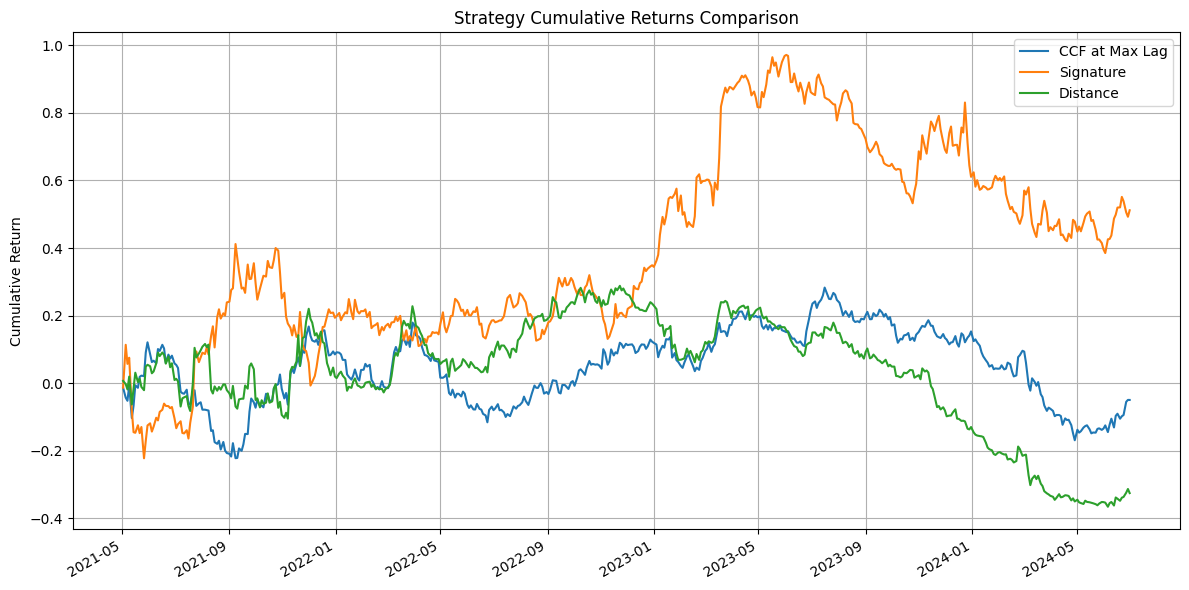

In [119]:
plt.figure(figsize=(12, 6))

((1 + 、).cumprod() - 1).plot(label='CCF at Max Lag')
((1 + ret_sig).cumprod() - 1).plot(label='Signature')
((1 + ret_dis).cumprod() - 1).plot(label='Distance')

plt.title("Strategy Cumulative Returns Comparison")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



In [114]:
def backtest_from_lead_lag_rolling_with_regime(prices, lead_lag_matrix_rolling, 
                                   cluster_signal=None, quantile=0.1):
    log_returns = np.log(prices).diff()
    log_returns.index = pd.to_datetime(log_returns.index)
    log_returns = log_returns.sort_index() 

    daily_returns = []
    backtest_dates = []

    for date in lead_lag_matrix_rolling.index:
        date = pd.Timestamp(date)
        matrix = lead_lag_matrix_rolling.loc[date]

        if matrix.isnull().all().all():
            continue

        # 获取 regime
        cluster_val = None
        if cluster_signal is not None:
            cluster_val = cluster_signal.get(date, np.nan)
        if pd.isna(cluster_val):
            continue

        # 根据 regime 决定操作逻辑
        lead_scores = matrix.mean(axis=1)
        top_thresh = lead_scores.quantile(1 - quantile)
        bottom_thresh = lead_scores.quantile(quantile)

        if cluster_val == 1:
            # 牛市：做多 leader，做空 follower
            leaders = lead_scores[lead_scores >= top_thresh].index
            followers = lead_scores[lead_scores <= bottom_thresh].index

        elif cluster_val == 2:
            # 熊市：反向策略——做多 follower，做空 leader
            followers = lead_scores[lead_scores >= top_thresh].index
            leaders = lead_scores[lead_scores <= bottom_thresh].index

        elif cluster_val == 0:
            # 震荡市：市场中性或缩小仓位
            leaders = lead_scores[lead_scores <= bottom_thresh].index
            followers = lead_scores[lead_scores >= top_thresh].index
            # 或者缩小头寸规模，比如不处理，或 daily_ret *= 0.5

        else:
            continue  # 其他未知 cluster，跳过

        if len(leaders) == 0 or len(followers) == 0:
            continue

        try:
            idx = log_returns.index.get_indexer([date], method='pad')[0]
            next_day = log_returns.index[idx + 1]
        except (IndexError, KeyError):
            continue

        r = log_returns.loc[next_day]

        long_leg = r[leaders].dropna().mean()
        short_leg = r[followers].dropna().mean()
        daily_ret = long_leg - short_leg

        # 可以在这里加入 regime-specific scaling
        if cluster_val == 0:
            daily_ret *= 0.5  # 比如震荡市减仓

        daily_returns.append(daily_ret)
        backtest_dates.append(next_day)

    returns = pd.Series(daily_returns, index=backtest_dates, name="strategy_return")
    
    return returns
ret_ccf_with = backtest_from_lead_lag_rolling_with_regime(
    prices=prices,
    lead_lag_matrix_rolling=lead_lag_ccf,
    cluster_signal=cluster_signal,
    quantile=0.1
)

ret_sig_with = backtest_from_lead_lag_rolling_with_regime(
    prices=prices,
    lead_lag_matrix_rolling=lead_lag_sig,
    cluster_signal=cluster_signal,
    quantile=0.1
)

ret_dis_with = backtest_from_lead_lag_rolling_with_regime(
    prices=prices,
    lead_lag_matrix_rolling=lead_lag_dis,
    cluster_signal=cluster_signal,
    quantile=0.1
)

stats_ccf = evaluate_strategy(ret_ccf_with)
stats_sig = evaluate_strategy(ret_sig_with)
stats_dis = evaluate_strategy(ret_dis_with)

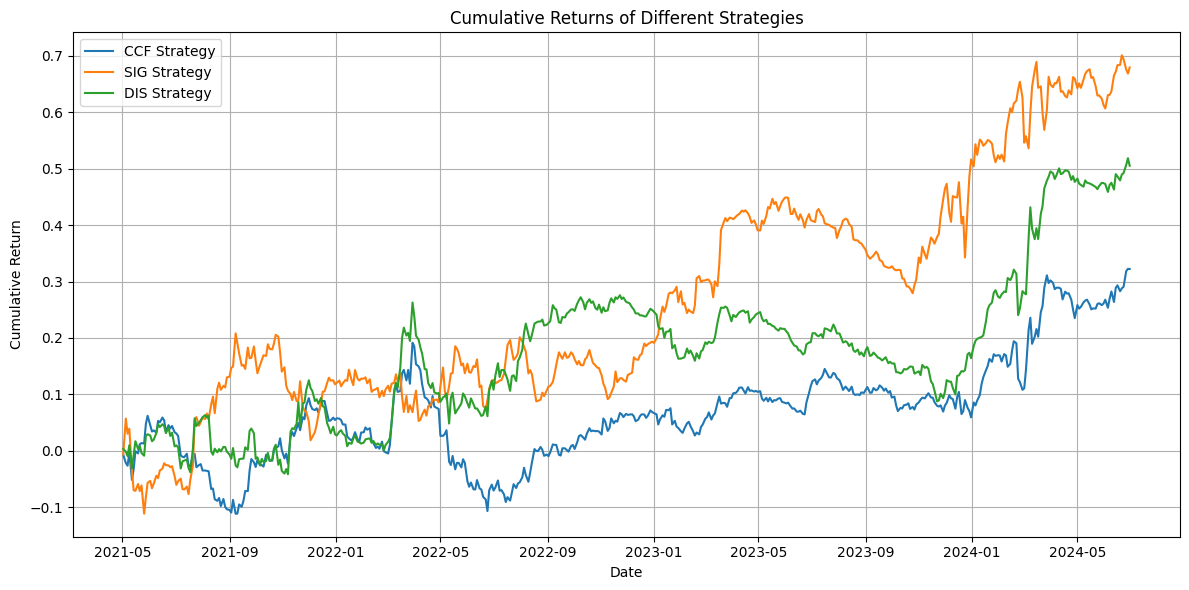

In [115]:
import matplotlib.pyplot as plt

# 累计收益
cum_ret_ccf = (1 + ret_ccf_with).cumprod() - 1
cum_ret_sig = (1 + ret_sig_with).cumprod() - 1
cum_ret_dis = (1 + ret_dis_with).cumprod() - 1


# 可视化
plt.figure(figsize=(12, 6))
plt.plot(cum_ret_ccf, label='CCF Strategy')
plt.plot(cum_ret_sig, label='SIG Strategy')
plt.plot(cum_ret_dis, label='DIS Strategy')


plt.title("Cumulative Returns of Different Strategies")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [116]:
# 汇总成表格查看
import pandas as pd

result_df = pd.DataFrame({
    "CCF": stats_ccf,
    "Signature": stats_sig,
    "Distance": stats_dis
}).T  # 转置，策略在行上

# 美化显示
print(result_df.round(3))



           Annual Return (%)  Sharpe Ratio  Volatility (%)  Max Drawdown (%)
CCF                   15.250         0.784          20.887           -29.817
Signature             30.124         1.186          24.789           -18.933
Distance              23.088         1.040          22.351           -21.445


In [39]:
def extract_labels(lead_lag_matrix_rolling, quantile=0.2):
    """
    返回每天每个资产的标签：1=leader, -1=follower, 0=其他
    """
    labels_dict = {}

    for date, matrix in lead_lag_matrix_rolling.items():
        lead_scores = matrix.mean(axis=1)
        top = lead_scores.quantile(1 - quantile)
        bottom = lead_scores.quantile(quantile)

        labels = pd.Series(0, index=lead_scores.index)
        labels[lead_scores >= top] = 1
        labels[lead_scores <= bottom] = -1
        labels_dict[pd.Timestamp(date)] = labels

    return pd.DataFrame(labels_dict).T  # index=date, columns=assets

labels_ccf = extract_labels(lead_lag_ccf, quantile=0.2)
labels_sig = extract_labels(lead_lag_sig, quantile=0.2)


In [29]:
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import jaccard_score

# 按天比较
jaccard_scores = []
ari_scores = []
valid_dates = []

for date in labels_ccf.index.intersection(labels_sig.index):
    l1 = labels_ccf.loc[date]
    l2 = labels_sig.loc[date]

    # 只对两者都不为0的资产计算 ARI
    common = l1.index.intersection(l2.index)
    y1 = l1.loc[common].values
    y2 = l2.loc[common].values

    # Jaccard: 只比较 leader 集合
    jaccard = jaccard_score((y1 == 1), (y2 == 1))
    ari = adjusted_rand_score(y1, y2)

    jaccard_scores.append(jaccard)
    ari_scores.append(ari)
    valid_dates.append(date)


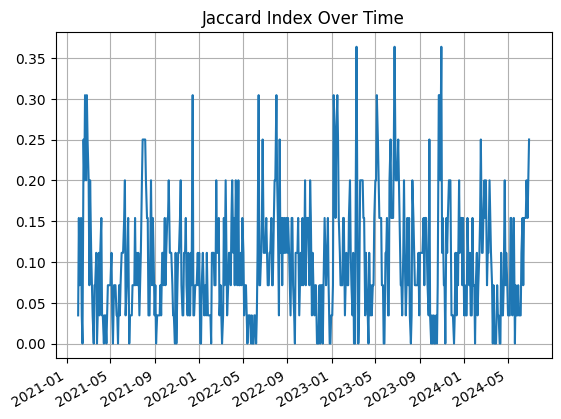

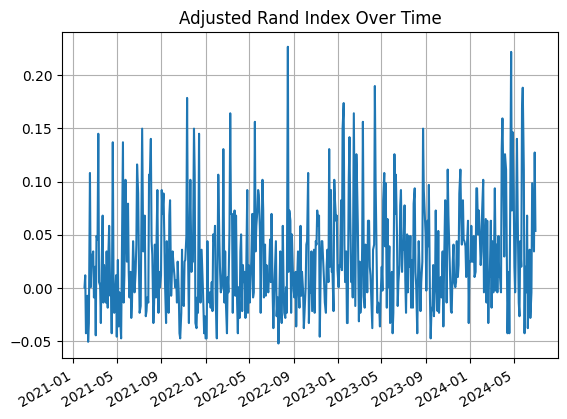

In [30]:
pd.Series(jaccard_scores, index=valid_dates).plot(title="Jaccard Index Over Time")
plt.grid(True); plt.show()

pd.Series(ari_scores, index=valid_dates).plot(title="Adjusted Rand Index Over Time")
plt.grid(True); plt.show()


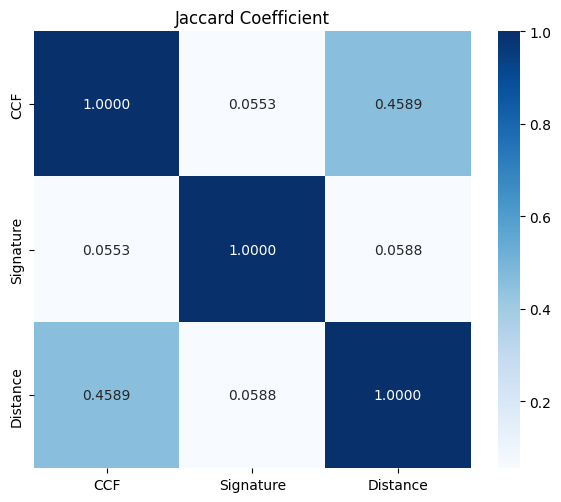

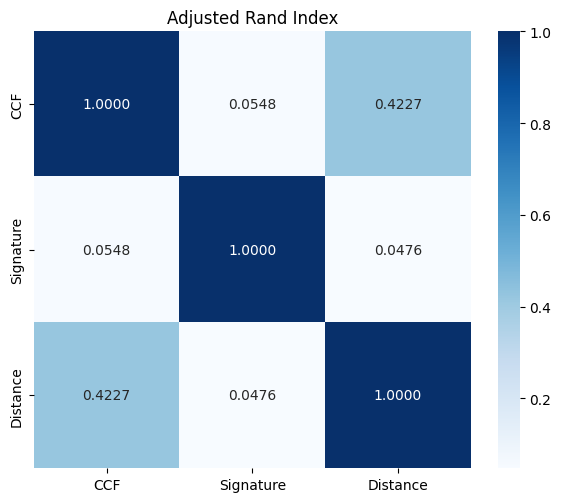

In [124]:
import pandas as pd
import numpy as np
from sklearn.metrics import adjusted_rand_score, jaccard_score
import seaborn as sns
import matplotlib.pyplot as plt

def compare_lead_lag_methods(method_to_matrix: dict, quantile=0.2, save_path=None):
    """
    比较多个 lead-lag 方法在 leader/follower 标签上的一致性（Jaccard & ARI）。
    
    参数：
        method_to_matrix: dict[str, dict[datetime, pd.DataFrame]]
            每种方法对应的 rolling lead-lag 矩阵
        quantile: float
            top/bottom quantile 用于定义 leader/follower
        save_path: str or None
            若提供则保存图像（自动添加 _jaccard / _ari 后缀）

    返回：
        jaccard_matrix, ari_matrix, labels_dict
    """

    def extract_labels(rolling_matrix, q):
        res = {}
        for date, mat in rolling_matrix.items():
            if mat is None or mat.isnull().all().all():
                continue
            scores = mat.mean(axis=1)
            top = scores.quantile(1 - q)
            bottom = scores.quantile(q)
            labels = pd.Series(0, index=scores.index)
            labels[scores >= top] = 1
            labels[scores <= bottom] = -1
            res[pd.Timestamp(date)] = labels
        return pd.DataFrame(res).T  # 行是日期，列是资产

    # 提取标签矩阵
    labels_dict = {method: extract_labels(matrix, quantile)
                   for method, matrix in method_to_matrix.items()}
    
    methods = list(labels_dict.keys())
    jaccard_matrix = pd.DataFrame(index=methods, columns=methods, dtype=float)
    ari_matrix = pd.DataFrame(index=methods, columns=methods, dtype=float)

    for method_i in methods:
        for method_j in methods:
            j_scores, a_scores = [], []
            df1, df2 = labels_dict[method_i], labels_dict[method_j]
            common_dates = df1.index.intersection(df2.index)
            for date in common_dates:
                y1, y2 = df1.loc[date], df2.loc[date]
                common_assets = y1.index.intersection(y2.index)
                v1, v2 = y1.loc[common_assets].values, y2.loc[common_assets].values
                if len(np.unique(v1)) > 1 and len(np.unique(v2)) > 1:
                    jaccard = jaccard_score(v1 == 1, v2 == 1)  # 只看 leader 相似性
                    ari = adjusted_rand_score(v1, v2)          # 看整体聚类一致性
                    j_scores.append(jaccard)
                    a_scores.append(ari)
            jaccard_matrix.loc[method_i, method_j] = np.mean(j_scores) if j_scores else np.nan
            ari_matrix.loc[method_i, method_j] = np.mean(a_scores) if a_scores else np.nan

    # 🔹 单独画 Jaccard 图
    plt.figure(figsize=(6, 5))
    sns.heatmap(jaccard_matrix, annot=True, fmt=".4f", cmap="Blues", square=True)
    plt.title("Jaccard Coefficient")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path.replace(".png", "_jaccard.png"))
    plt.show()

    # 🔹 单独画 ARI 图
    plt.figure(figsize=(6, 5))
    sns.heatmap(ari_matrix, annot=True, fmt=".4f", cmap="Blues", square=True)
    plt.title("Adjusted Rand Index")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path.replace(".png", "_ari.png"))
    plt.show()

    return jaccard_matrix, ari_matrix, labels_dict


method_to_matrix = {
    "CCF": lead_lag_ccf,
    "Signature": lead_lag_sig,
    "Distance": lead_lag_dis
}

jac, ari, labels = compare_lead_lag_methods(
    method_to_matrix=method_to_matrix,
    quantile=0.1,
    save_path="lead_lag_comparison.png"
)


Log return index sorted?: True
Log return index unique?: True
Lead-lag matrix index sorted?: True
[2021-02-02] Long (Leaders): 0.00116, Short (Followers): 0.03738, Return: -0.03622
[2021-02-04] Long (Leaders): 0.02531, Short (Followers): -0.00961, Return: 0.03492
[2021-02-06] Long (Leaders): -0.02237, Short (Followers): -0.04914, Return: 0.02677
[2021-02-10] Long (Leaders): 0.02789, Short (Followers): 0.04879, Return: -0.02090
[2021-02-12] Long (Leaders): 0.08403, Short (Followers): 0.04274, Return: 0.04129
[2021-02-14] Long (Leaders): -0.06141, Short (Followers): -0.05699, Return: -0.00443
[2021-02-17] Long (Leaders): 0.02418, Short (Followers): 0.04050, Return: -0.01632
[2021-02-19] Long (Leaders): 0.03217, Short (Followers): 0.02636, Return: 0.00581
[2021-02-21] Long (Leaders): 0.03155, Short (Followers): 0.02081, Return: 0.01074
[2021-02-24] Long (Leaders): 0.03995, Short (Followers): 0.07903, Return: -0.03909
[2021-02-26] Long (Leaders): -0.00385, Short (Followers): -0.00541, Retu

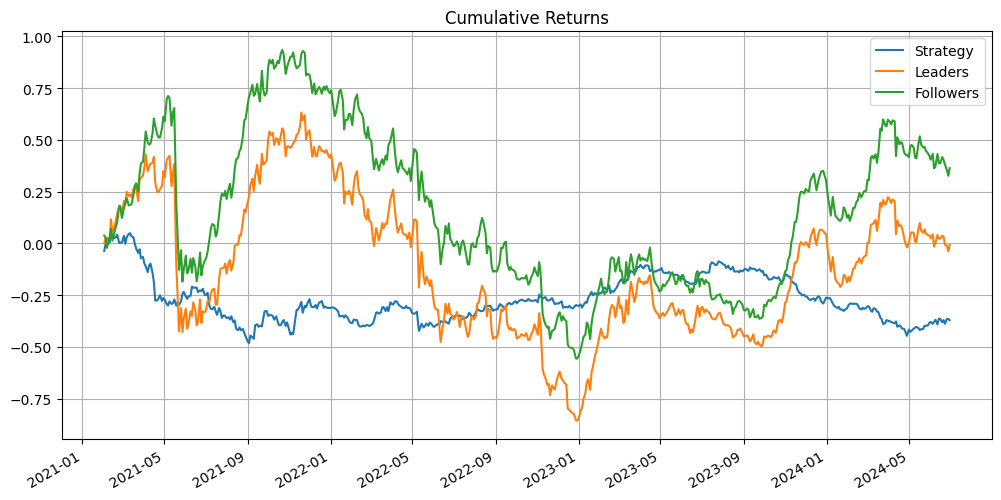

Annual Return (%)   -18.854330
Sharpe Ratio         -0.672939
Volatility (%)       25.990174
Max Drawdown (%)    -44.797778
dtype: float64


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def backtest_from_lead_lag_rolling(prices, lead_lag_matrix_rolling, quantile=0.2):
    log_returns = np.log(prices).diff()
    log_returns.index = pd.to_datetime(log_returns.index)
    log_returns = log_returns.sort_index()
    
    print("Log return index sorted?:", log_returns.index.is_monotonic_increasing)
    print("Log return index unique?:", log_returns.index.is_unique)

    # Ensure rolling matrix index matches returns index
    aligned_dates = lead_lag_matrix_rolling.index.intersection(log_returns.index)
    lead_lag_matrix_rolling = lead_lag_matrix_rolling.loc[aligned_dates]

    daily_returns = []
    backtest_dates = []
    leader_returns = []
    follower_returns = []

    print("Lead-lag matrix index sorted?:", lead_lag_matrix_rolling.index.is_monotonic_increasing)

    for date in lead_lag_matrix_rolling.index:
        date = pd.Timestamp(date)
        matrix = lead_lag_matrix_rolling.loc[date]

        if matrix.isnull().all().all():
            continue

        lead_scores = matrix.mean(axis=1)
        top_thresh = lead_scores.quantile(1 - quantile)
        bottom_thresh = lead_scores.quantile(quantile)

        followers = lead_scores[lead_scores >= top_thresh].index
        leaders = lead_scores[lead_scores <= bottom_thresh].index

        if len(leaders) == 0 or len(followers) == 0:
            continue

        # 获取当前日期之后的一个交易日
        try:
            idx = log_returns.index.get_loc(date)
            next_day = log_returns.index[idx + 1]
        except (IndexError, KeyError):
            continue

        # 获取下一个交易日的 log return
        r = log_returns.loc[next_day]

        long_leg = r[leaders].dropna().mean()
        short_leg = r[followers].dropna().mean()
        daily_ret = long_leg - short_leg

        # 存储结果
        daily_returns.append(daily_ret)
        backtest_dates.append(next_day)
        leader_returns.append(long_leg)
        follower_returns.append(short_leg)

        print(f"[{next_day.date()}] Long (Leaders): {long_leg:.5f}, Short (Followers): {short_leg:.5f}, Return: {daily_ret:.5f}")

    returns = pd.Series(daily_returns, index=backtest_dates, name="strategy_return")
    leaders_series = pd.Series(leader_returns, index=backtest_dates, name="leaders_return")
    followers_series = pd.Series(follower_returns, index=backtest_dates, name="followers_return")

    return returns, leaders_series, followers_series


def evaluate_strategy(returns, risk_free_rate=0):
    ann_factor = 252
    excess_ret = returns - risk_free_rate / ann_factor

    sharpe = excess_ret.mean() / excess_ret.std() * np.sqrt(ann_factor)
    volatility = returns.std() * np.sqrt(ann_factor)
    cumulative_return = (1 + returns).cumprod() - 1
    max_drawdown = (cumulative_return - cumulative_return.cummax()).min()
    annual_return = (1 + cumulative_return[-1]) ** (ann_factor / len(returns)) - 1

    stats = {
        'Annual Return (%)': annual_return * 100,
        'Sharpe Ratio': sharpe,
        'Volatility (%)': volatility * 100,
        'Max Drawdown (%)': max_drawdown * 100,
    }
    return stats



returns, leaders, followers = backtest_from_lead_lag_rolling(prices, lead_lag_matrix_rolling)
stats = evaluate_strategy(returns)


plt.figure(figsize=(12, 6))
returns.cumsum().plot(label="Strategy")
leaders.cumsum().plot(label="Leaders")
followers.cumsum().plot(label="Followers")
plt.legend()
plt.title("Cumulative Returns")
plt.grid(True)
plt.show()

print(pd.Series(stats))


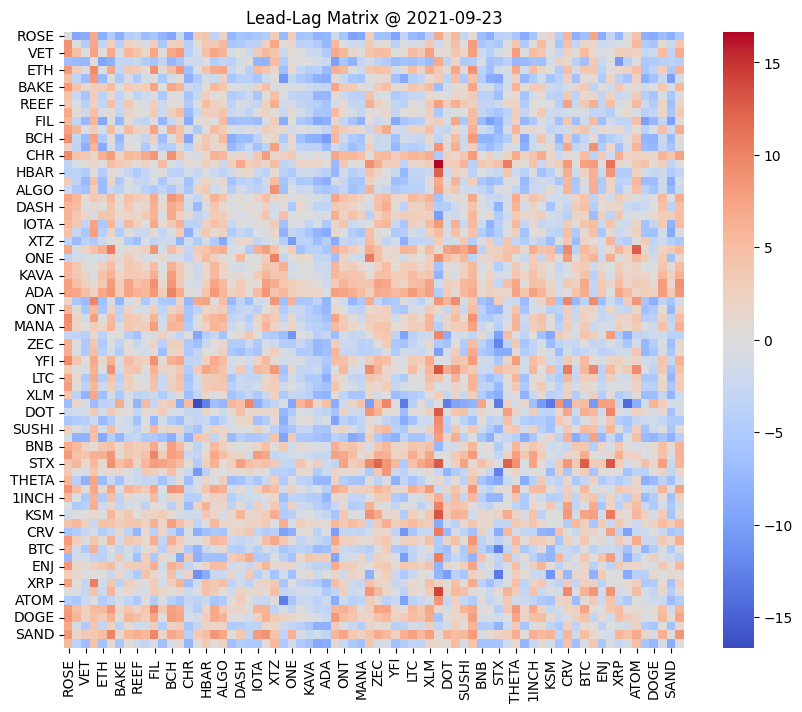

平均非对称性（|A - A^T|）：7.1422


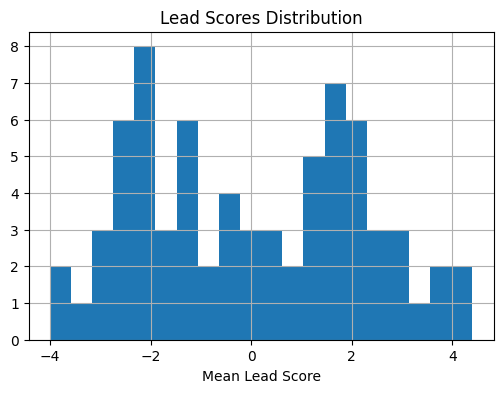

10天内最常被识别为 leader 的资产：
RUNE     8
CRV      8
UNI      8
SUSHI    8
AAVE     7
1INCH    7
AVAX     7
FTM      6
SNX      6
CAKE     5
dtype: int64


In [200]:
import matplotlib.pyplot as plt
import seaborn as sns

# 选择某个时间点检查
sample_date = lead_lag_matrix_rolling.index[100]  # 可以换成你关心的日期
matrix = lead_lag_matrix_rolling.loc[sample_date]

# --- 1. 可视化 lead-lag 矩阵 ---
plt.figure(figsize=(10, 8))
sns.heatmap(matrix, cmap="coolwarm", center=0, annot=False)
plt.title(f"Lead-Lag Matrix @ {sample_date.date()}")
plt.show()

# --- 2. 统计对称性 ---
asymmetry = (matrix - matrix.T).abs()
asymmetry_mean = asymmetry.values[np.triu_indices_from(asymmetry, k=1)].mean()
print(f"平均非对称性（|A - A^T|）：{asymmetry_mean:.4f}")

# --- 3. 每只资产的平均lead值（得分分布） ---
lead_scores = matrix.mean(axis=1)

plt.figure(figsize=(6, 4))
lead_scores.hist(bins=20)
plt.title("Lead Scores Distribution")
plt.xlabel("Mean Lead Score")
plt.grid(True)
plt.show()

# --- 4. 哪些资产经常是leaders ---
# 统计前10个日期中被归为leaders次数
quantile = 0.2
leader_counter = {}

for date in lead_lag_matrix_rolling.index[:10]:  # 可扩展到更多
    m = lead_lag_matrix_rolling.loc[date]
    s = m.mean(axis=1)
    top_thresh = s.quantile(1 - quantile)
    leaders = s[s >= top_thresh].index
    for asset in leaders:
        leader_counter[asset] = leader_counter.get(asset, 0) + 1

# 排序输出
leader_df = pd.Series(leader_counter).sort_values(ascending=False)
print("10天内最常被识别为 leader 的资产：")
print(leader_df.head(10))


In [168]:
prices

,ROSE,ANKR,VET,NEAR,ETH,EOS,BAKE,GRT,REEF,INJ,...,ENJ,CAKE,XRP,TRX,ATOM,AAVE,DOGE,NEO,SAND,QTUM
ticker,,,,,,,,,,,,,,,,,,,,,
1/1/2021,0.04210,0.008912,0.019052,1.3587,728.91,2.6378,NaN,0.36169,0.012224,4.0817,...,0.13561,NaN,0.23746,0.02685,5.861,90.711,0.005680,14.461,0.036973,2.268
1/2/2021,0.04095,0.008557,0.019993,1.4124,774.56,2.6321,NaN,0.32751,0.011317,3.6083,...,0.13156,NaN,0.22064,0.02721,5.420,85.768,0.010526,14.426,0.038107,2.249
1/3/2021,0.04129,0.008610,0.026226,1.4707,978.28,2.7985,NaN,0.29857,0.009871,4.4294,...,0.13500,NaN,0.22540,0.02949,5.829,93.778,0.009821,16.024,0.040928,2.466
1/4/2021,0.04135,0.008397,0.024598,1.3868,1041.43,2.8191,NaN,0.30888,0.010121,4.3500,...,0.14105,NaN,0.23565,0.03095,6.044,114.271,0.009761,16.372,0.040432,2.515
1/5/2021,0.04394,0.008499,0.027964,1.4953,1099.56,2.8862,NaN,0.33823,0.010981,4.5700,...,0.14654,NaN,0.22573,0.02852,6.196,119.689,0.009970,16.868,0.041700,2.612
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6/26/2024,0.09229,0.030890,0.025950,5.1770,3371.44,0.5750,0.2740,0.21870,0.001415,23.0400,...,0.19980,2.151,0.46980,0.12268,6.791,94.460,0.122760,11.340,0.334000,2.566
6/27/2024,0.09734,0.031490,0.026690,5.2230,3450.44,0.5894,0.2786,0.21780,0.001451,23.2400,...,0.19620,2.182,0.47530,0.12201,6.965,93.460,0.127110,11.620,0.340700,2.607
6/28/2024,0.09674,0.030630,0.026650,4.9620,3380.15,0.5875,0.2672,0.20730,0.001418,23.0700,...,0.19100,2.134,0.47160,0.12321,6.729,93.640,0.123060,11.400,0.336100,2.571


In [39]:
log_ret_type = ''  # _residuals
lookback = 30
update_freq = 1
correlation_method = 'mutual_information'
method = 'signature'

lead_lag_matrix_rolling = pd.read_pickle('./data/binance_pickled_data/lead_lag_matrix_rolling' + '_lookback_' + str(lookback) +
                                         '_update_freq_' + str(update_freq) + log_ret_type + '_' + correlation_method + '_' + method + '.pkl')

In [173]:
'''GENERATE CLUSTERS_ROLLING AND FLOW_GRAPH_ROLLING'''
log_ret_type = ''  # _residuals
lookback = 30
update_freq = 1
correlation_method = 'mutual_information'
method = 'signature'
daily_ret.index = pd.to_datetime(daily_ret.index)

lead_lag_matrix_rolling = pd.read_pickle('./data/binance_pickled_data/lead_lag_matrix_rolling' + '_lookback_' + str(lookback) +
                                         '_update_freq_' + str(update_freq) + log_ret_type + '_' + correlation_method + '_' + method + '.pkl')

clusters_rolling = lead_lag_matrix_rolling.apply(get_ordered_clustering, num_clusters=6)

clusters_rolling.to_pickle('./data/binance_pickled_data/clusters_rolling_lookback_' + str(lookback) + '_update_freq_' +
                           str(update_freq) + log_ret_type + '_' + correlation_method + '_' + method + '.pkl')
flow_graph_rolling = get_flow_graph_rolling(lead_lag_matrix_rolling, clusters_rolling, normalise=True)
flow_graph_rolling.to_pickle('./data/binance_pickled_data/flow_graph_rolling_lookback_' + str(lookback) + '_update_freq_' +
                             str(update_freq) + log_ret_type + '_' + correlation_method + '_' + method + '.pkl')

In [174]:
clusters_rolling.head()

,ROSE,ANKR,VET,NEAR,ETH,EOS,BAKE,GRT,REEF,INJ,...,ENJ,CAKE,XRP,TRX,ATOM,AAVE,DOGE,NEO,SAND,QTUM
2021-02-01,3,3,3,3,3,5,4,5,3,4,...,3,4,2,2,5,4,5,1,3,1
2021-02-03,3,5,3,0,3,4,1,1,5,0,...,3,1,4,4,0,1,5,2,3,2
2021-02-05,2,5,2,2,2,3,1,1,2,1,...,2,1,5,3,1,1,3,4,2,4
2021-02-09,0,4,4,0,1,3,1,1,0,1,...,2,2,3,4,2,2,2,4,2,4
2021-02-11,1,2,3,1,2,4,2,1,1,1,...,3,0,4,4,0,0,0,3,0,4


In [185]:
analysis = []

for date in lead_lag_matrix_rolling.index:
    if date not in clusters_rolling.index:
        continue

    lead_lag = lead_lag_matrix_rolling.loc[date]
    clusters = clusters_rolling.loc[date]

    if lead_lag.isnull().all().all():
        continue

    # Step 1: 每个资产的 lead_score
    lead_scores = lead_lag.mean(axis=1)

    # Step 2: quantile 挑出 top leaders
    top_thresh = lead_scores.quantile(1 - quantile)
    top_leaders = lead_scores[lead_scores >= top_thresh].index

    # Step 3: 构造 cluster 映射
    clusters = clusters.astype("Int64")
    asset_cluster = pd.Series(clusters.to_dict())

    # Step 4: 按 cluster 排名 → 生成映射：原 cluster ID → rank（0 是最强）
    cluster_lead_scores = lead_scores.groupby(asset_cluster).mean().sort_values(ascending=False)
    cluster_id_map = {orig_id: new_rank for new_rank, orig_id in enumerate(cluster_lead_scores.index)}
    normalized_cluster = asset_cluster.map(cluster_id_map)  # 每个资产的新 cluster ID（按得分排序）

    # Step 5: 提取最强的 cluster（编号0）
    top_cluster_assets = normalized_cluster[normalized_cluster == 0].index

    # Step 6: 计算重合
    overlap = set(top_leaders).intersection(set(top_cluster_assets))
    overlap_ratio = len(overlap) / len(top_leaders)

    analysis.append({
        "date": date,
        "overlap_with_top_leaders": len(overlap),
        "overlap_ratio": overlap_ratio,
        "top_leader_count": len(top_leaders),
        "top_cluster_size": len(top_cluster_assets),
    })

df_analysis = pd.DataFrame(analysis).set_index("date")


<AxesSubplot:title={'center':'Overlap between top quantile leaders and top cluster'}, xlabel='date'>

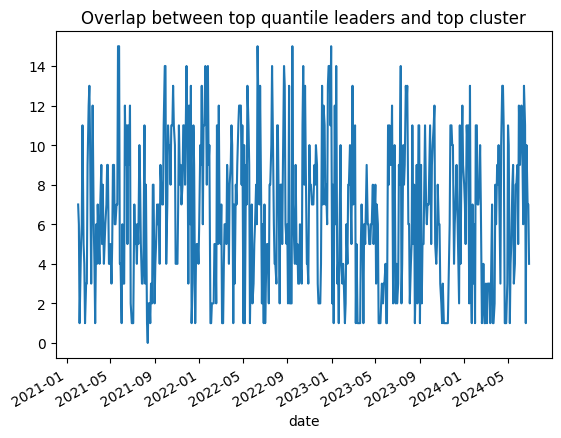

In [187]:
df_analysis['overlap_with_top_leaders'].plot(title="Overlap between top quantile leaders and top cluster")


In [80]:
###############################################################################################################################

In [ ]:
############################################################################################################################################################################################

In [ ]:
############################################################################################################################################################################################

In [ ]:
###################################################################################################################################################################################################